<a href="https://colab.research.google.com/github/nuralfiyanti/PCVK_Ganjil2026/blob/main/WEEK05_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama  : Nur Alfiyanti

NIM   : 244107020055

Kelas : TI-3E

## **C.Ketentuan Pengumpulan**

Seluruh percobaan pada modul ini dikerjakan dua tahap: lebih dulu dengan citra contoh untuk
memastikan kode Anda sudah benar, kemudian dengan citra KTM milik Anda sendiri sebagai bahan
analisis. Parameter percobaan diturunkan dari NIM Anda, sehingga setiap mahasiswa bekerja pada
nilai yang berbeda.

**A. Citra Pribadi**

Lakukan akuisisi dengan ketentuan berikut ini, setelah akuisisi lakukan cropping sehingga tidak
ada background pada ktp anda:
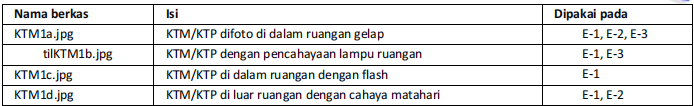

Selain citra KTM di atas, Anda juga memerlukan citra contoh lena.jpg dan lena_lc.jpg yang sudah
disediakan pada percobaan kali ini. Citra contoh dipakai hanya untuk memastikan kode Anda sudah
benar, sedangkan citra KTM dipakai sebagai bahan analisis dan penilaian.

*Catatan privasi: KTM memuat data pribadi. Apabila repositori GitHub Anda bersifat publik, tutup area foto dan NIM pada citra yang ditampilkan di bagian yang dapat diakses publik, dan simpan citra asli pada Google Drive yang tidak dibagikan ke publik.*

**B. Parameter Pribadi Berbasis NIM**

Nilai parameter pada seluruh percobaan tidak dipilih sembarangan, melainkan dihitung dari tiga
digit terakhir NIM Anda yang disebut N. Dengan cara ini setiap mahasiswa bekerja pada titik operasi
yang berbeda, dan setiap angka pada laporan dapat dihitung ulang oleh dosen.

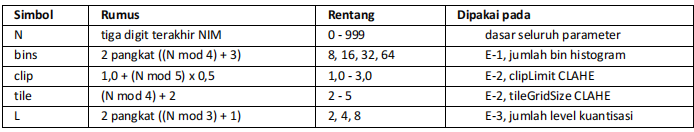



**C. Sel Identitas (Wajib Menjadi Sel Pertama)**

Sel berikut wajib menjadi sel pertama notebook Week5, dijalankan, dan keluarannya ikut tersimpan pada berkas yang dikumpulkan. Notebook tanpa sel ini tidak dinilai.

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Nur Alfiyanti'
NIM  = '244107020055'

N     = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Nur Alfiyanti
NIM    : 244107020055 | N = 55
bins   : 64
clip   : 1.0
tile   : 5
L      : 4
WAKTU  : 2026-10-02 05:12:24 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 1b3c0e9ba44fc6cd


## **D. Ulasan Teori**

di PDF Modul 5 – Histogram, Histogram Equalization, dan Dithering

## **E. Percobaan Praktikum**

**Cara mengerjakan percobaan pada modul ini**

Setiap percobaan dikerjakan dalam dua tahap.
  
  - Tahap 1, verifikasi dengan citra contoh. Jalankan kode Anda pada citra contoh yang disebutkan, yaitu lena.jpg atau lena_lc.jpg, lalu bandingkan outputnya dengan gambar contoh pada modul. Keluaran Anda harus sama. Bila berbeda, perbaiki kode lebih dulu sebelum melanjutkan.

  - Tahap 2, penerapan pada citra sendiri. Ulangi percobaan yang sama pada citra KTM hasil akuisisi Anda pada Pertemuan 2. Hasil tahap inilah yang dianalisis dan dinilai.
  
  Tampilkan keluaran kedua tahap pada notebook dan beri judul yang memuat NIM pada setiap citra. Tetapkan dua variabel folder berikut sekali saja, lalu pakai di seluruh percobaan.

  CONTOH = '/content/drive/MyDrive/PCVK/Images' # citra contoh bersama
  
  BASE = '/content/drive/MyDrive/PCVK/Images/' + NIM # citra KTM milik Anda

### **E-1 Percobaan Histogram**

**1. Buka https://colab.research.google.com/. Setelah dipastikan bahwa Google Colab terhubung dengan GitHub Anda, lanjutkan dengan memilih repository yang telah digunakan pada praktikum minggu lalu, lalu ubah nama berkas menjadi
"Week5_<No Absen>.ipynb". Salin sel identitas dari subbab Ketentuan Pengumpulan
sebagai sel pertama notebook**.

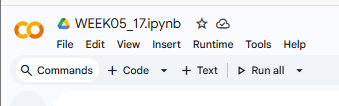

**Kemudian import folder yang ada di Drive Anda dengan cara sebagai berikut.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2.Import beberapa library berikut yang akan digunakan selama uji coba praktikum minggu ke-5 berikut.**

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

In [ ]:
CONTOH = '/content/drive/MyDrive/PCVK'
BASE   = '/content/drive/MyDrive/PCVK/KTM'

**3. Membuat histogram citra berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena.jpg dan cocokkan keluarannya dengan gambar contoh pada modul; setelah cocok, tahap 2 ulangi dengan citra KTM1b.jpg milik Anda sendiri**.

*Gambar berikut adalah keluaran yang harus Anda peroleh pada tahap 1 dengan citra contoh. Bila
keluaran Anda berbeda, perbaiki kode lebih dulu sebelum melanjutkan ke tahap 2 dengan citra KTM
Anda*.

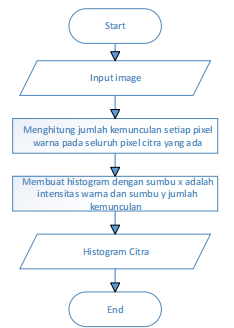

Tahap 1: lena.jpg.jpeg

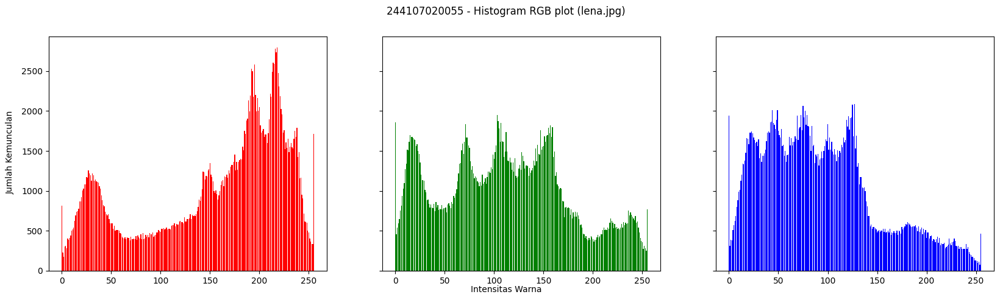

In [ ]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (lena.jpg)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

Tahap 2: KTP1b.jpeg


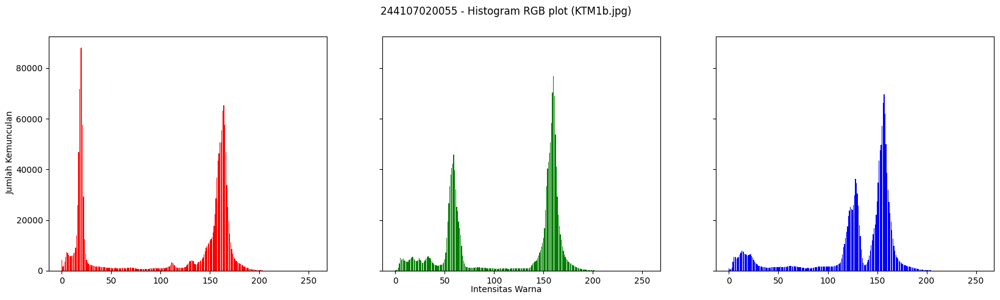

In [ ]:
#membuat histogram image (manual) - KTM1b.jpg
img = cv.imread(BASE + '/tilKTM1b.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red   = [0]*256
green = [0]*256
blue  = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]]   += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]]  += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot (KTM1b.jpg)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

### **Pertanyaan Praktikum E1**

**1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.**

lena.jpg
Selisih maksimum manual vs numpy.histogram      : 0
Selisih maksimum manual vs cv.calcHist          : 0
Selisih maksimum numpy.histogram vs cv.calcHist : 0


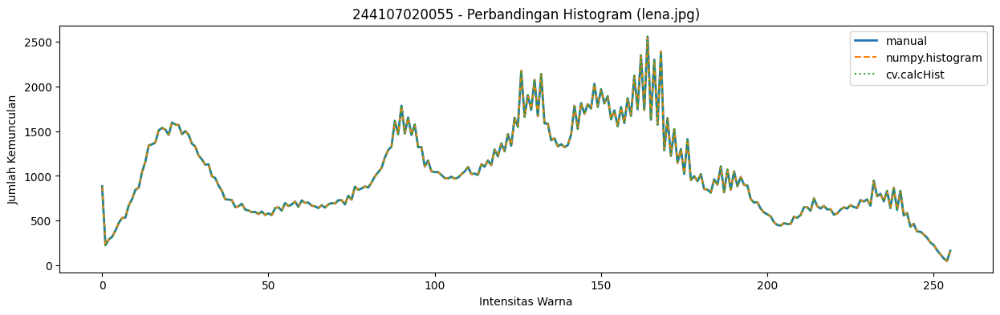

KTM1b.jpg
Selisih maksimum manual vs numpy.histogram      : 0
Selisih maksimum manual vs cv.calcHist          : 0
Selisih maksimum numpy.histogram vs cv.calcHist : 0


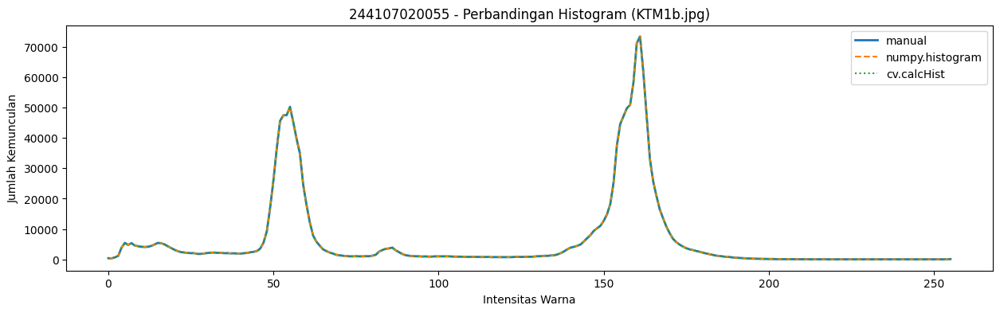

In [ ]:
def histogram_manual(img_gray):
    h = np.zeros(256, dtype=np.int64)
    for y in range(img_gray.shape[0]):
        for x in range(img_gray.shape[1]):
            h[img_gray[y, x]] += 1
    return h

def bandingkan_histogram(path, nama_tampil):
    gray = cv.imread(path, cv.IMREAD_GRAYSCALE)
    h_manual = histogram_manual(gray)
    h_numpy, _ = np.histogram(gray, bins=256, range=(0, 256))
    h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

    print(nama_tampil)
    print('Selisih maksimum manual vs numpy.histogram      :', np.max(np.abs(h_manual - h_numpy)))
    print('Selisih maksimum manual vs cv.calcHist          :', np.max(np.abs(h_manual - h_cv)))
    print('Selisih maksimum numpy.histogram vs cv.calcHist :', np.max(np.abs(h_numpy - h_cv)))

    plt.figure(figsize=(15,4))
    plt.plot(h_manual, label='manual', linewidth=2)
    plt.plot(h_numpy, label='numpy.histogram', linestyle='--')
    plt.plot(h_cv, label='cv.calcHist', linestyle=':')
    plt.title(NIM + ' - Perbandingan Histogram (' + nama_tampil + ')')
    plt.xlabel('Intensitas Warna')
    plt.ylabel('Jumlah Kemunculan')
    plt.legend()
    plt.show()

bandingkan_histogram(CONTOH + '/lena.jpg.jpeg', 'lena.jpg')     # tahap 1
bandingkan_histogram(BASE + '/tilKTM1b.jpeg', 'KTM1b.jpg')      # tahap 2

**Penjelasan:**

Ketiga metode menghasilkan selisih maksimum 0, baik pada lena.jpg maupun KTM1b, karena semuanya menghitung hal yang sama: jumlah kemunculan tiap nilai intensitas piksel (0–255). Perbedaannya hanya pada cara implementasi. Metode manual menelusuri setiap piksel satu per satu dengan perulangan bersarang sehingga paling lambat, sedangkan numpy.histogram dan cv.calcHist sudah dioptimasi di level rendah (vektorisasi/C) sehingga jauh lebih cepat, terutama untuk citra berukuran besar.

**2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.**

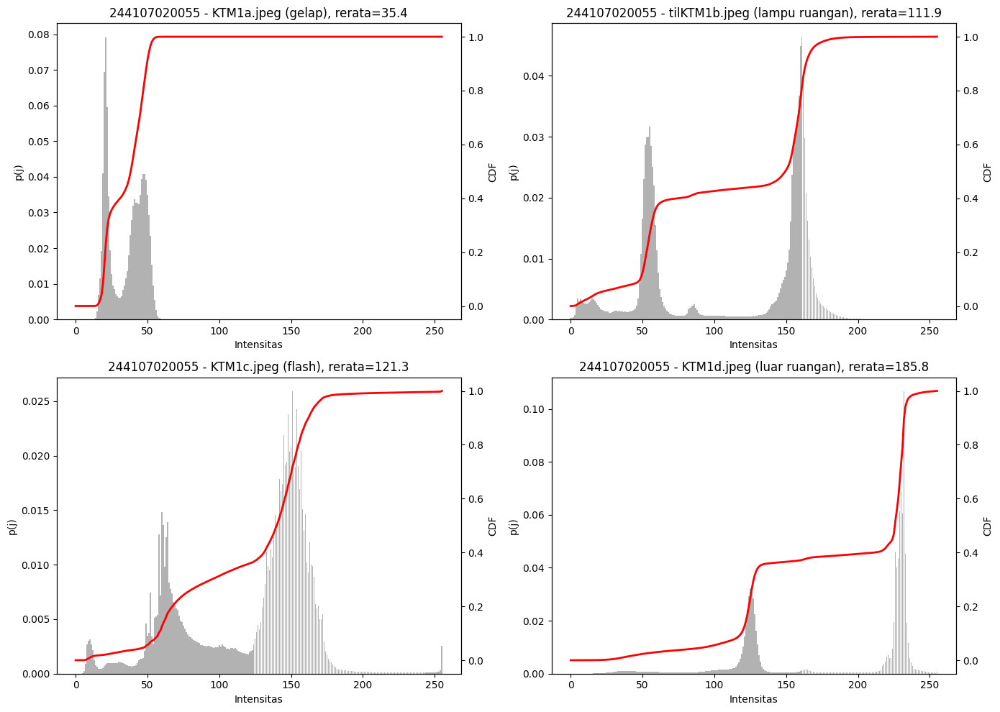

Rerata kecerahan tiap citra:
  KTM1a.jpeg: 35.38
  tilKTM1b.jpeg: 111.92
  KTM1c.jpeg: 121.28
  KTM1d.jpeg: 185.80


In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

files = ['KTM1a.jpeg', 'tilKTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']
ket   = ['gelap', 'lampu ruangan', 'flash', 'luar ruangan']

rerata_kecerahan = {}

for i, fname in enumerate(files):
    gray = cv.imread(BASE + '/' + fname, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(gray)
    p = h / gray.size           # normalisasi
    cdf = np.cumsum(p)          # distribusi kumulatif

    rerata_kecerahan[fname] = gray.mean()

    ax2 = axs[i].twinx()
    axs[i].bar(np.arange(256), p, color='gray', alpha=0.6, label='p(j)')
    ax2.plot(np.arange(256), cdf, color='red', linewidth=2, label='CDF')

    axs[i].set_title(NIM + f' - {fname} ({ket[i]}), rerata={gray.mean():.1f}')
    axs[i].set_xlabel('Intensitas')
    axs[i].set_ylabel('p(j)')
    ax2.set_ylabel('CDF')

plt.tight_layout()
plt.show()

print('Rerata kecerahan tiap citra:')
for k, v in rerata_kecerahan.items():
    print(f'  {k}: {v:.2f}')

**Penjelasan:**

Citra paling gelap adalah KTM1a.jpeg (rerata 35,4) dan paling terang KTM1d.jpeg (rerata 185,8). Pada KTM1a, kurva CDF naik sangat curam di intensitas rendah (0–60) dan langsung mendekati 1, karena hampir semua piksel bernilai gelap, sesuai kondisi akuisisi di ruangan gelap tanpa cahaya tambahan. ada KTM1d, CDF tetap landai hingga intensitas ~200, baru naik tajam di 220–255, karena mayoritas piksel bernilai terang, sesuai kondisi di luar ruangan dengan cahaya matahari langsung.

Kesimpulan: makin terang kondisi pencahayaan saat akuisisi, makin kurva CDF bergeser dan naik tajam ke arah intensitas tinggi.

**3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.**

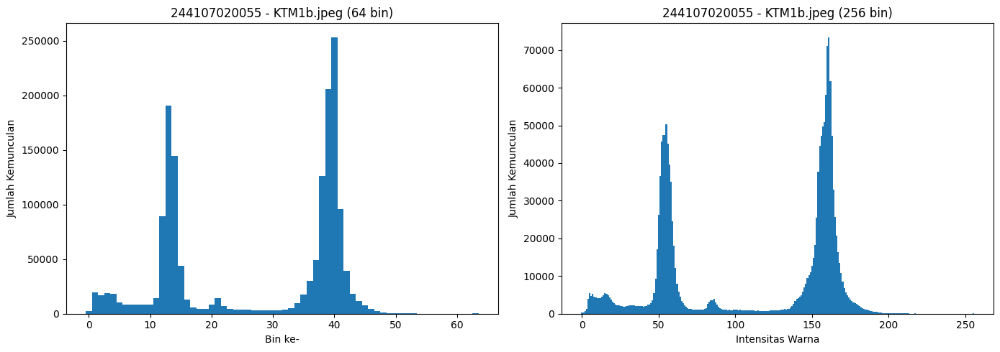

In [ ]:
gray = cv.imread(BASE + '/tilKTM1b.jpeg', cv.IMREAD_GRAYSCALE)

h_bins = cv.calcHist([gray], [0], None, [PARAM['bins']], [0, 256]).flatten()
h_256  = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()

fig, axs = plt.subplots(1, 2, figsize=(14,5))

axs[0].bar(np.arange(PARAM['bins']), h_bins, width=1.0)
axs[0].set_title(NIM + ' - KTM1b.jpeg (%d bin)' % PARAM['bins'])
axs[0].set_xlabel('Bin ke-')
axs[0].set_ylabel('Jumlah Kemunculan')

axs[1].bar(np.arange(256), h_256, width=1.0)
axs[1].set_title(NIM + ' - KTM1b.jpeg (256 bin)')
axs[1].set_xlabel('Intensitas Warna')
axs[1].set_ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

**Penjelasan:**

arameter bins saya bernilai 64, sehingga setiap bin mewakili gabungan 4 level intensitas dari total 256 level yang ada. Hal ini membuat dua puncak yang semula terlihat tajam dan terpisah pada histogram 256 bin (di sekitar intensitas 50 dan 160) menjadi lebih tumpul dan lebih tinggi pada histogram 64 bin, karena piksel dari beberapa level berdekatan digabung menjadi satu batang. Pengurangan jumlah bin ini menghilangkan detail variasi halus antar level yang berdekatan, seperti pola bergerigi dan celah kosong pada histogram, meskipun bentuk umum distribusinya *jumlah* dan posisi puncak masih dapat dikenali.

## **E-2 Percobaan Histogram Equalization**

**1.Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses, berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.**

*Gambar berikut adalah keluaran yang harus Anda peroleh pada tahap 1 dengan citra contoh. Bila keluaran Anda berbeda, perbaiki kode lebih dulu sebelum melanjutkan ke tahap 2 dengan citra KTM Anda.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math, os, glob

CONTOH = '/content/drive/MyDrive/PCVK'
BASE   = '/content/drive/MyDrive/PCVK/KTM'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Tahap 1: lena_lc.jpg.jpeg

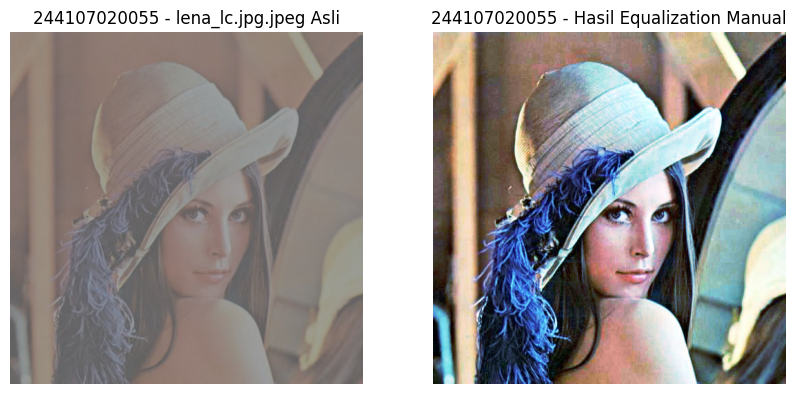

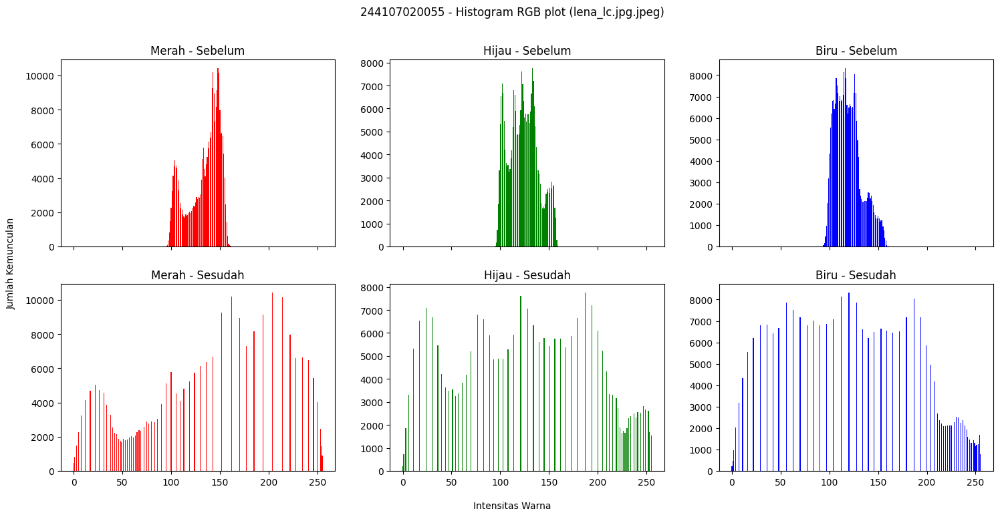

In [31]:
def histogram_equalization_manual(channel):
    h = histogram_manual(channel)
    p = h / channel.size
    cdf = np.cumsum(p)
    s = np.round(255 * cdf).astype(np.uint8)
    hasil = s[channel]
    return hasil

bgr = cv.imread(CONTOH + '/lena_lc.jpg.jpeg')

b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - lena_lc.jpg.jpeg Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Hasil Equalization Manual')
plt.axis('off')
plt.show()

# Histogram RGB
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
fig.suptitle(NIM + ' - Histogram RGB plot (lena_lc.jpg.jpeg)')

warna = [('Merah', 'red'), ('Hijau', 'green'), ('Biru', 'blue')]
kanal_asli  = [r, g, b]
kanal_hasil = [r_eq, g_eq, b_eq]

for i, (nama, w) in enumerate(warna):
    axs[0, i].bar(np.arange(256), np.bincount(kanal_asli[i].ravel(), minlength=256), color=w)
    axs[0, i].set_title(nama + ' - Sebelum')

    axs[1, i].bar(np.arange(256), np.bincount(kanal_hasil[i].ravel(), minlength=256), color=w)
    axs[1, i].set_title(nama + ' - Sesudah')

fig.text(0.08, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
plt.show()

Tahap 2: KTM1a.jpeg

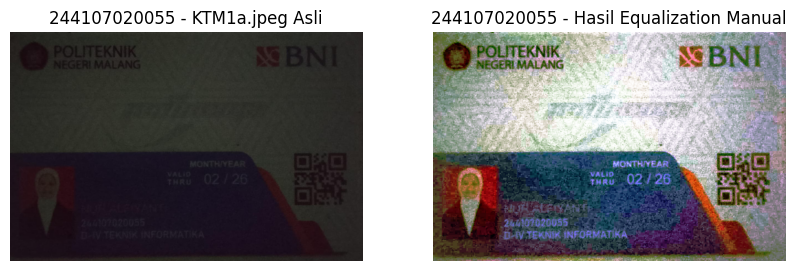

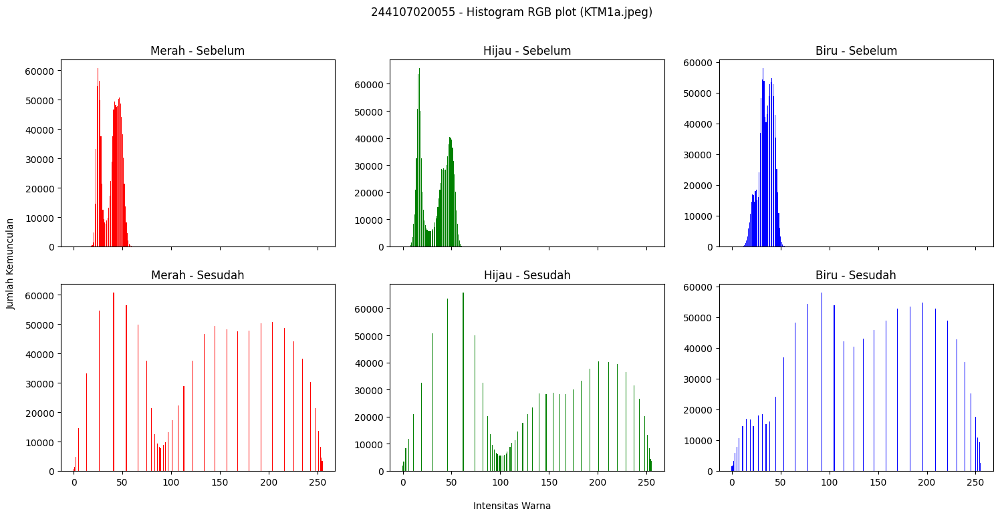

In [30]:
bgr = cv.imread(BASE + '/KTM1a.jpeg')

b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1a.jpeg Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Hasil Equalization Manual')
plt.axis('off')
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
fig.suptitle(NIM + ' - Histogram RGB plot (KTM1a.jpeg)')

warna = [('Merah', 'red'), ('Hijau', 'green'), ('Biru', 'blue')]
kanal_asli  = [r, g, b]
kanal_hasil = [r_eq, g_eq, b_eq]

for i, (nama, w) in enumerate(warna):
    axs[0, i].bar(np.arange(256), np.bincount(kanal_asli[i].ravel(), minlength=256), color=w)
    axs[0, i].set_title(nama + ' - Sebelum')

    axs[1, i].bar(np.arange(256), np.bincount(kanal_hasil[i].ravel(), minlength=256), color=w)
    axs[1, i].set_title(nama + ' - Sesudah')

fig.text(0.08, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
plt.show()

**2.Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada potongan kode berikut ini.**

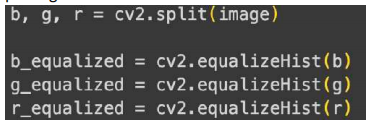

**Lengkapi potongan kode tersebut. Bandingkan hasil equalizeHist dengan hasil
implementasi manual Anda dengan menghitung selisih maksimum antara keduanya,
baik pada lena_lc.jpg maupun pada KTM1a.jpg, lalu jelaskan penyebab selisih tersebut apabila tidak nol.**

Tahap 1: lena_lc.jpg.jpeg

Selisih maksimum manual vs cv.equalizeHist (lena_lc.jpg.jpeg): 0


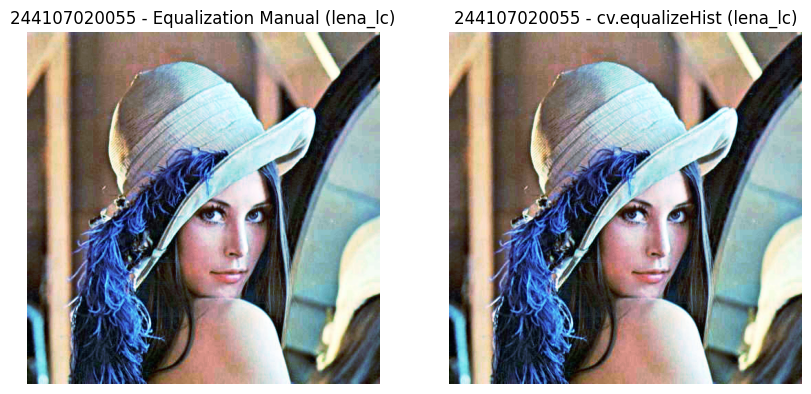

In [ ]:
bgr = cv.imread(CONTOH + '/lena_lc.jpg.jpeg')

b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

b, g, r = cv.split(bgr)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)
hasil_cv = cv.merge([b_equalized, g_equalized, r_equalized])

selisih = np.max(np.abs(hasil_eq.astype(np.int16) - hasil_cv.astype(np.int16)))
print('Selisih maksimum manual vs cv.equalizeHist (lena_lc.jpg.jpeg):', selisih)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization Manual (lena_lc)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_cv, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - cv.equalizeHist (lena_lc)')
plt.axis('off')
plt.show()

Tahap 2: KTM1a.jpeg

Selisih maksimum manual vs cv.equalizeHist (KTM1a.jpeg): 0


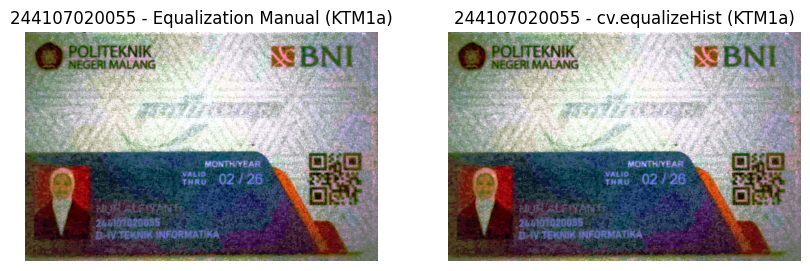

In [ ]:
bgr = cv.imread(BASE + '/KTM1a.jpeg')

b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

b, g, r = cv.split(bgr)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)
hasil_cv = cv.merge([b_equalized, g_equalized, r_equalized])

selisih = np.max(np.abs(hasil_eq.astype(np.int16) - hasil_cv.astype(np.int16)))
print('Selisih maksimum manual vs cv.equalizeHist (KTM1a.jpeg):', selisih)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization Manual (KTM1a)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_cv, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - cv.equalizeHist (KTM1a)')
plt.axis('off')
plt.show()

**Penjelasan:**

Selisih maksimum antara hasil ekualisasi manual dan cv.equalizeHist adalah 0, baik pada lena_lc.jpg.jpeg maupun KTM1a.jpeg. Ini menunjukkan implementasi manual saya sudah identik dengan fungsi bawaan OpenCV. Apabila selisih tidak nol, penyebabnya biasanya terletak pada perbedaan normalisasi CDF — cv.equalizeHist mengurangi nilai CDF dengan CDF piksel minimum sebelum dikalikan skala warna, sedangkan rumus manual langsung mengalikan CDF dengan 255. Namun karena citra uji saya memiliki piksel yang tersebar di hampir seluruh rentang intensitas, efek pengurangan tersebut tidak mengubah hasil pembulatan akhir ke nilai integer 8-bit, sehingga hasil kedua metode tetap sama persis.

**3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali
terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan
potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada
KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.**

Tahap 1: lena.jpg

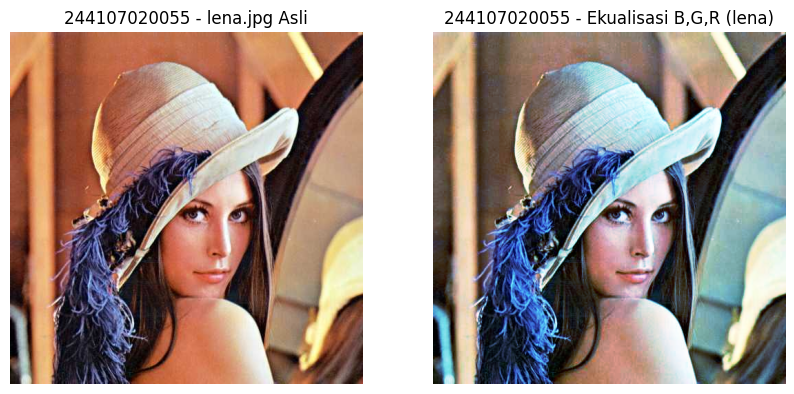

In [32]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

berkas = CONTOH + '/lena.jpg.jpeg'   # tahap 1
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - lena.jpg Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B,G,R (lena)')
plt.axis('off')
plt.show()

Tahap 2: KTM1d.jpeg

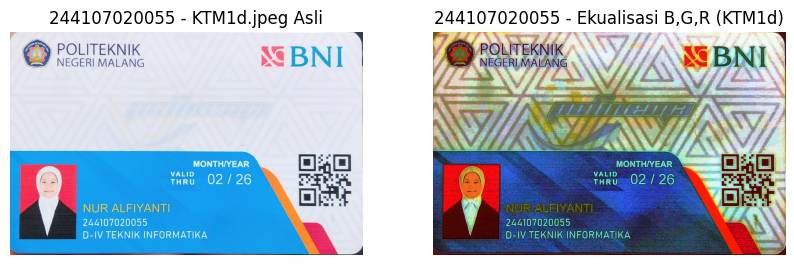

In [ ]:
berkas = BASE + '/KTM1d.jpeg'   # tahap 2
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1d.jpeg Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B,G,R (KTM1d)')
plt.axis('off')
plt.show()

**Penjelasan:**

Setelah ekualisasi dilakukan pada kanal B, G, R secara terpisah, kedua citra mengalami pergeseran warna dari aslinya. Pada lena.jpg, warna kulit bergeser menjadi keunguan dan latar belakang jadi lebih oranye. Pada KTM1d.jpeg pergeserannya lebih ekstrem: latar belakang biru solid berubah hijau pudar dan motif watermark yang sebelumnya tersembunyi jadi terlihat jelas.

Penyebabnya: tiap kanal dikontraskan sendiri-sendiri tanpa mempertimbangkan hubungan antar kanal, sehingga rasio warna asli (B:G:R) tiap piksel rusak dan warna hasil tidak lagi natural.

**4. Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna
YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang
menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal
L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan
KTM1d.jpg)**

Tahap 1 : lena.jpg

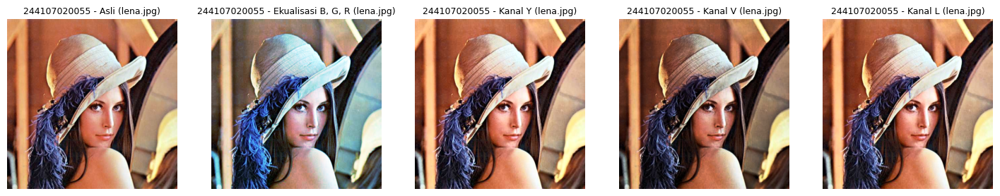

In [ ]:
berkas = CONTOH + '/lena.jpg.jpeg'
bgr = cv.imread(berkas)

# cara 1: tiap kanal diekualisasi sendiri-sendiri (dari Langkah 3)
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t + ' (lena.jpg)', fontsize=9)
    plt.axis('off')
plt.show()

Tahap 2 : KTP1d.jpeg

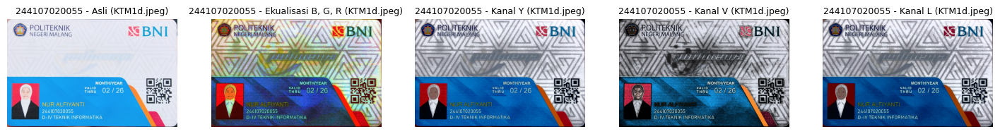

In [ ]:
berkas = BASE + '/' + 'KTM1d.jpeg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t + ' (KTM1d.jpeg)', fontsize=9)
    plt.axis('off')
plt.show()

**Penjelasan:**

Ekualisasi pada kanal terang saja (Y, V, atau L) menghasilkan warna yang jauh lebih mendekati aslinya dibanding ekualisasi B,G,R terpisah. Terbukti dari pergeseran Hue: B,G,R bergeser 73,26 derajat, sedangkan Y, V, L hanya 2,17–5,75 derajat. Pada KTM1d, background biru kartu tetap terjaga di ketiga kanal terang, berbeda dari hasil B,G,R yang berubah hijau pudar. Namun peningkatan kontrasnya tidak sedrastis B,G,R, sehingga ada trade-off antara menjaga warna asli dan memaksimalkan kontras.

**Perbedaan kedua cara ini tidak cukup dinilai dengan mata. Ukur pergeseran warnanya dengan membandingkan kanal Hue dengan citra asli. Kanal Hue menyimpan jenis warna, sehingga nilai yang berubah banyak berarti warna citra memang bergeser. Perhatikan bahwa Hue pada OpenCV bersifat melingkar pada rentang 0 sampai 179, jadi selisihnya dihitung lewat jalur terpendek.**

In [ ]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                   cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            185.8
Ekualisasi B, G, R                73.26            132.2
Kanal Y                            2.71            136.9
Kanal V                            2.17            111.9
Kanal L                            5.75            127.0


**Catat hasilnya pada tabel berikut.**

In [ ]:
catatan = [
    'Background biru, foto wajah, warna khas KTM',
    'Warna berubah drastis, background jadi hijau pudar',
    'Warna asli hampir terjaga, background tetap biru',
    'Warna asli paling terjaga, pergeseran Hue terkecil',
    'Warna asli terjaga, sedikit lebih bergeser dari kanal V'
]

data_tabel = []
for t, c, k in zip(judul, citra, catatan):
    geser = geser_hue(bgr, c) * 2 if t != 'Asli' else None
    terang = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    data_tabel.append([t, geser, terang, k])

df = pd.DataFrame(data_tabel, columns=['Cara Ekualisasi', 'Pergeseran Hue (derajat)', 'Rerata Kecerahan', 'Catatan Pengamatan Visual'])
df

,Cara Ekualisasi,Pergeseran Hue (derajat),Rerata Kecerahan,Catatan Pengamatan Visual
0,Asli,NaN,185.765619,"Background biru, foto wajah, warna khas KTM"
1,"Ekualisasi B, G, R",73.255272,132.190132,"Warna berubah drastis, background jadi hijau p..."
2,Kanal Y,2.706996,136.900099,"Warna asli hampir terjaga, background tetap biru"
3,Kanal V,2.171818,111.888963,"Warna asli paling terjaga, pergeseran Hue terk..."
4,Kanal L,5.755000,127.015415,"Warna asli terjaga, sedikit lebih bergeser dar..."


**Jawab pertanyaan berikut berdasarkan angka pada tabel Anda, bukan hanya dari pengamatan mata:**

**1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada
citra Anda?**

**Jawaban:**

Cara yang menghasilkan pergeseran Hue paling besar adalah ekualisasi kanal B, G, R secara terpisah, dengan nilai rata-rata pergeseran Hue sebesar 73,26 derajat. Nilai ini jauh lebih besar dibanding ketiga cara kanal terang lainnya (Kanal Y = 2,71°, Kanal V = 2,17°, Kanal L = 5,75°), membuktikan bahwa mengekualisasi tiap kanal warna secara independen menyebabkan pergeseran warna yang signifikan.

**2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis
nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra
dikembalikan ke ruang warna BGR.**

**Jawaban:**

Meskipun secara teori mengekualisasi kanal terang saja (Y, V, atau L) seharusnya menjaga Hue tetap sama, pada praktiknya tetap terjadi pergeseran kecil (Kanal Y = 2,71°, Kanal V = 2,17°, Kanal L = 5,75°). Penyebab utamanya adalah pemotongan nilai (clipping): saat kecerahan piksel ditingkatkan drastis, nilai R, G, B hasil konversi balik ke BGR bisa melebihi batas 0–255, terutama pada bagian citra yang sudah terang. Nilai yang melebihi batas ini dipotong paksa ke 0 atau 255, sehingga merusak proporsi relatif antar kanal R, G, B yang sebenarnya menentukan Hue. Pembulatan (rounding) ke bilangan bulat uint8 juga ikut berkontribusi, tapi efeknya jauh lebih kecil dibanding clipping.

**3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan
alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.**

**Jawaban:**

Berdasarkan data pada tabel, Kanal V (HSV) paling sesuai untuk foto KTM saya, karena menghasilkan pergeseran Hue paling kecil (2,17°), berarti warna asli citra (terutama background biru kartu dan foto wajah) paling terjaga dibanding Kanal Y dan Kanal L. Hal ini penting untuk mempertahankan keaslian warna dokumen identitas, seperti warna background biru khas KTM yang menjadi ciri visual dokumen tersebut.

**4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa.**

**Jawaban:**



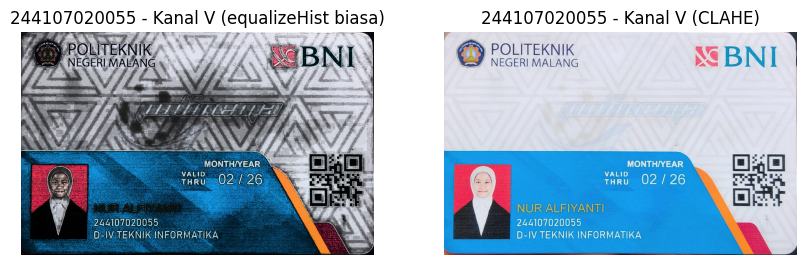

Kanal V (equalizeHist) -> geser Hue: 2.17, rerata terang: 111.9
Kanal V (CLAHE)        -> geser Hue: 0.51, rerata terang: 178.7


In [ ]:
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
v_clahe = clahe.apply(v)
he_v_clahe = cv.cvtColor(cv.merge([h, sat, v_clahe]), cv.COLOR_HSV2BGR)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(he_v, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Kanal V (equalizeHist biasa)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(he_v_clahe, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Kanal V (CLAHE)')
plt.axis('off')
plt.show()

geser_biasa = geser_hue(bgr, he_v) * 2
geser_clahe = geser_hue(bgr, he_v_clahe) * 2
terang_biasa = cv.cvtColor(he_v, cv.COLOR_BGR2GRAY).mean()
terang_clahe = cv.cvtColor(he_v_clahe, cv.COLOR_BGR2GRAY).mean()

print('Kanal V (equalizeHist) -> geser Hue: %.2f, rerata terang: %.1f' % (geser_biasa, terang_biasa))
print('Kanal V (CLAHE)        -> geser Hue: %.2f, rerata terang: %.1f' % (geser_clahe, terang_clahe))

**Perbandingan:**

Dibandingkan equalizeHist biasa, CLAHE menghasilkan pergeseran Hue yang jauh lebih kecil (0,51° vs 2,17°) dan kecerahan yang lebih mendekati citra asli (178,7 vs 111,9, dengan asli 185,8). Namun perlu dicatat bahwa clipLimit saya bernilai 1,0 nilai terendah dalam rentang parameter (1,0–3,0), sehingga CLAHE pada dasarnya menerapkan penguatan kontras yang sangat ringan, mendekati citra aslinya. Ini menjelaskan mengapa pergeseran warnanya kecil: bukan semata karena sifat lokal CLAHE lebih unggul, tetapi karena clipLimit rendah membuat perubahan terhadap citra memang minim. Trade-off-nya, peningkatan keterbacaan detail kartu (teks, foto) pada hasil CLAHE juga tidak sedrastis equalizeHist biasa, karena kontras yang ditambahkan memang kecil. Dengan demikian, CLAHE pada parameter ini lebih unggul dari sisi menjaga warna asli, tetapi trade-off-nya adalah peningkatan kontras yang lebih terbatas dibanding ekualisasi global.

## **Pertanyaan Praktikum E2**

**1. Ekualisasi global pada citra KTM Anda**

a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.

b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.


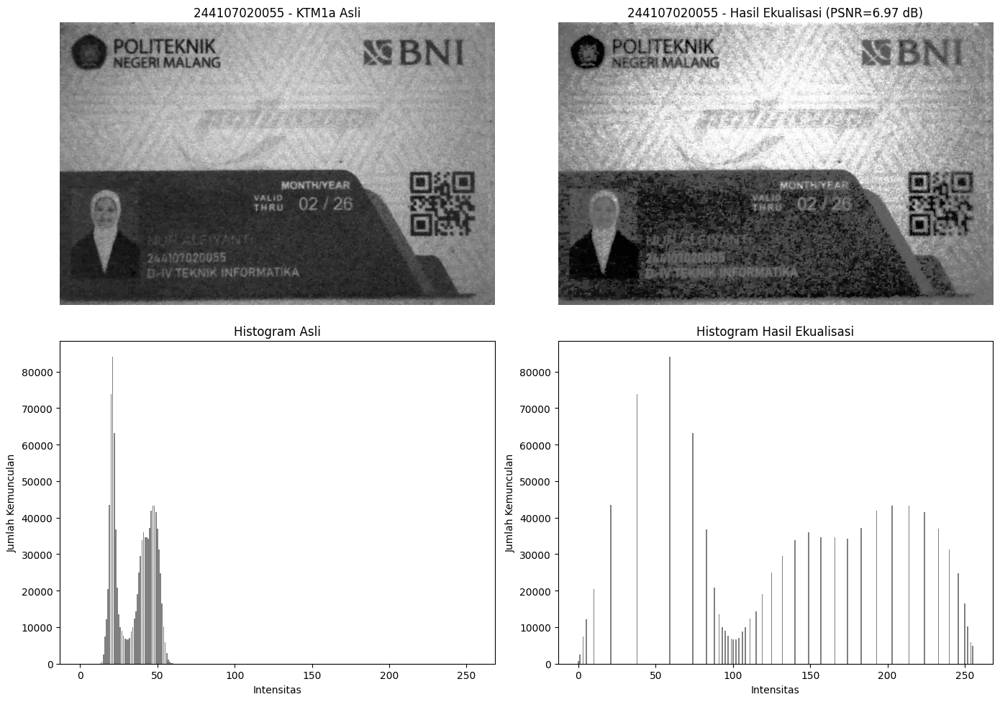

Nilai PSNR (KTM1a asli vs hasil ekualisasi): 6.97 dB


In [33]:
from math import log10, sqrt

def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

gray = cv.imread(BASE + '/' + 'KTM1a.jpeg', cv.IMREAD_GRAYSCALE)

# ekualisasi manual
hasil_manual = histogram_equalization_manual(gray)

# ekualisasi cv.equalizeHist
hasil_cv = cv.equalizeHist(gray)

# histogram untuk ditampilkan
h_asli   = histogram_manual(gray)
h_hasil  = histogram_manual(hasil_cv)

# PSNR
psnr_val = PSNR(gray, hasil_cv)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0,0].imshow(gray, cmap='gray')
axs[0,0].set_title(NIM + ' - KTM1a Asli')
axs[0,0].axis('off')

axs[0,1].imshow(hasil_cv, cmap='gray')
axs[0,1].set_title(NIM + f' - Hasil Ekualisasi (PSNR={psnr_val:.2f} dB)')
axs[0,1].axis('off')

axs[1,0].bar(np.arange(256), h_asli, color='gray')
axs[1,0].set_title('Histogram Asli')
axs[1,0].set_xlabel('Intensitas'); axs[1,0].set_ylabel('Jumlah Kemunculan')

axs[1,1].bar(np.arange(256), h_hasil, color='gray')
axs[1,1].set_title('Histogram Hasil Ekualisasi')
axs[1,1].set_xlabel('Intensitas'); axs[1,1].set_ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

print('Nilai PSNR (KTM1a asli vs hasil ekualisasi):', round(psnr_val, 2), 'dB')

**Penjelasan:**

Nilai PSNR antara citra asli dan citra hasil ekualisasi hanya 6,97 dB, tergolong sangat rendah. Hal ini terjadi karena PSNR mengukur selisih nilai piksel secara matematis terhadap citra asli, bukan mengukur kejelasan atau keterbacaan visual. Histogram equalization secara sengaja mengubah nilai piksel secara signifikan, terlihat dari histogram asli yang menumpuk sempit di rentang gelap (0–60) kemudian disebar paksa ke seluruh rentang 0–255 pada histogram hasil. Perubahan piksel yang sangat besar ini membuat MSE (mean squared error) terhadap citra asli menjadi tinggi, sehingga PSNR menjadi rendah, meskipun secara visual citra KTM saya terlihat jauh lebih terang dan detailnya (teks NIM, nama, foto) menjadi lebih mudah dibaca dibanding kondisi asli yang gelap.

**2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda**

**a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?**


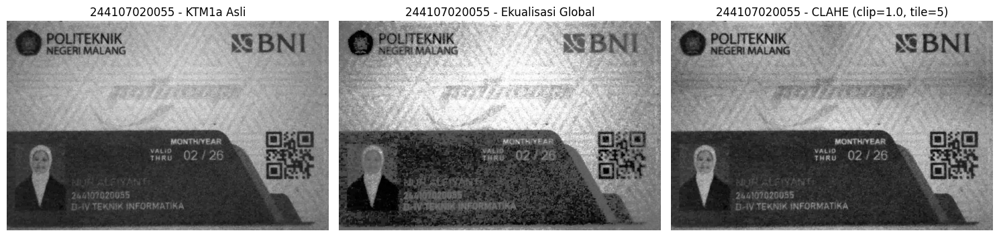

In [34]:
hasil_global = cv.equalizeHist(gray)

clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe = clahe.apply(gray)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - KTM1a Asli')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hasil_global, cmap='gray')
plt.title(NIM + ' - Ekualisasi Global')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil_clahe, cmap='gray')
plt.title(NIM + f" - CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})")
plt.axis('off')

plt.tight_layout()
plt.show()

**Jawaban:**

Berdasarkan hasil visual, CLAHE menghasilkan teks NIM dan nama yang lebih terbaca dibanding ekualisasi global. Ekualisasi global membuat motif watermark pada background kartu menjadi sangat menonjol dan mengganggu, sehingga teks di atasnya justru tenggelam di antara noise tersebut. CLAHE dengan clipLimit=1,0 menghasilkan peningkatan kontras yang lebih terkendali per wilayah kecil (tile 5×5), sehingga detail teks lebih jelas tanpa watermark yang berlebihan.


**b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.**

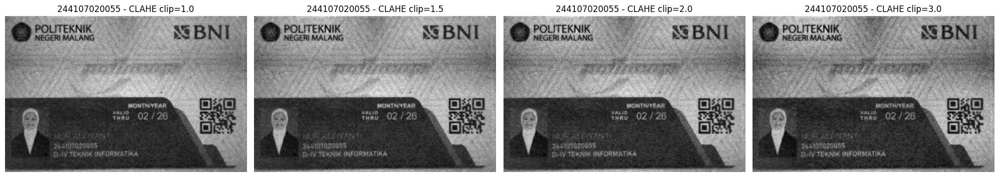

In [35]:
gray = cv.imread(BASE + '/' + 'KTM1a.jpeg', cv.IMREAD_GRAYSCALE)

clip_list = [1.0, 1.5, 2.0, 3.0]   # PARAM['clip']=1.0 disertakan sebagai pembanding

plt.figure(figsize=(20,5))
for i, clip_val in enumerate(clip_list, 1):
    clahe = cv.createCLAHE(clipLimit=clip_val, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe.apply(gray)

    plt.subplot(1, len(clip_list), i)
    plt.imshow(hasil, cmap='gray')
    plt.title(NIM + f' - CLAHE clip={clip_val}')
    plt.axis('off')

plt.tight_layout()
plt.show()

**Jawaban:**

Semakin tinggi clipLimit, kontras citra meningkat secara bertahap, namun karena rentang yang dicoba (1,0–3,0) relatif sempit, perbedaan antar nilai terlihat halus. Noise/motif watermark pada background mulai sedikit lebih menonjol pada clip=3,0 dibanding clip=1,0, terutama di area dekat foto dan sudut kanan atas kartu. Nilai clip=1,0 (PARAM saya) menghasilkan citra paling halus dengan noise paling minim, karena ini adalah batas bawah rentang parameter modul, sehingga penguatan kontrasnya paling ringan di antara keempat nilai yang dicoba. Saya memilih clip=1,0 sebagai nilai terbaik untuk citra saya, karena sudah cukup meningkatkan keterbacaan teks NIM dan nama dibanding citra asli, tanpa memunculkan noise watermark berlebihan seperti pada clip=3,0.

## **E-3 Tugas Praktikum *Dithering***

**1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].**

*Gambar berikut adalah keluaran yang harus Anda peroleh pada tahap 1 dengan citra contoh. Bila
keluaran Anda berbeda, perbaiki kode lebih dulu sebelum melanjutkan ke tahap 2 dengan citra KTM
Anda.*

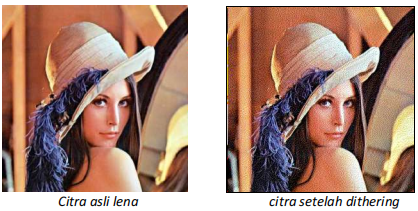

In [38]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                  img[y,   x+1] += error * 7 / 16
            if x > 0     and y+1 < H:      img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                  img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y+1 < H:      img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

Tahap 1: lena.jpg.jpeg

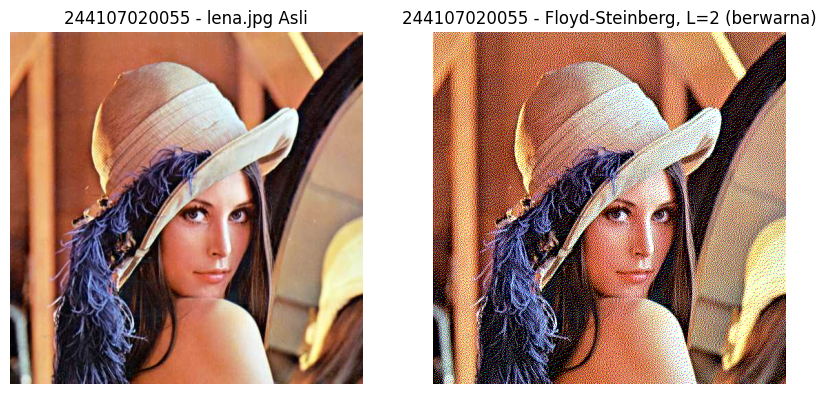

In [39]:
bgr = cv.imread(CONTOH + '/lena.jpg.jpeg')

b, g, r = cv.split(bgr)
b_dither = floyd_steinberg(b, L=2)
g_dither = floyd_steinberg(g, L=2)
r_dither = floyd_steinberg(r, L=2)
hasil_dither = cv.merge([b_dither, g_dither, r_dither])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - lena.jpg Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Floyd-Steinberg, L=2 (berwarna)')
plt.axis('off')
plt.show()

Tahap 2: tilKTM1b.jpeg, L = PARAM['L'] = 4

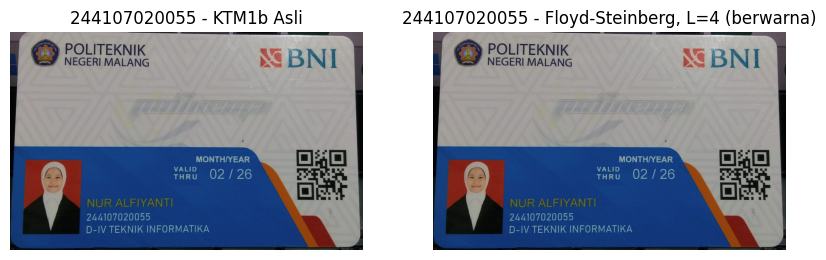

In [40]:
bgr = cv.imread(BASE + '/' + 'tilKTM1b.jpeg')

b, g, r = cv.split(bgr)
b_dither = floyd_steinberg(b, L=PARAM['L'])
g_dither = floyd_steinberg(g, L=PARAM['L'])
r_dither = floyd_steinberg(r, L=PARAM['L'])
hasil_dither = cv.merge([b_dither, g_dither, r_dither])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1b Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + f" - Floyd-Steinberg, L={PARAM['L']} (berwarna)")
plt.axis('off')
plt.show()

**Penjelasan:**

Dithering diterapkan per kanal warna (B, G, R) lalu digabung kembali. Hasil pada lena.jpg cocok dengan contoh modul, membuktikan kode sudah benar. Pada KTM1b dengan PARAM['L']=4 (4 level per kanal, total 64 kombinasi warna), teks NIM dan nama tetap terbaca dan warna dasar kartu (biru khas KTM) masih dikenali dengan baik, karena jumlah level yang lebih banyak dibanding L=2 membuat transisi warna lebih halus meski kedalaman warna tetap dipangkas signifikan dari jutaan warna asli.

**2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.**

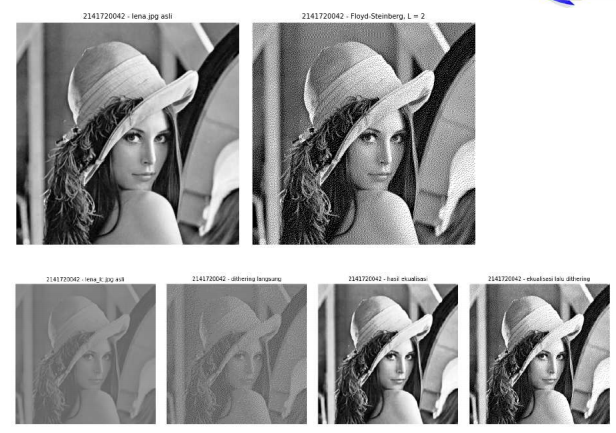

Tahap 1: lena_lc.jpg.jpeg

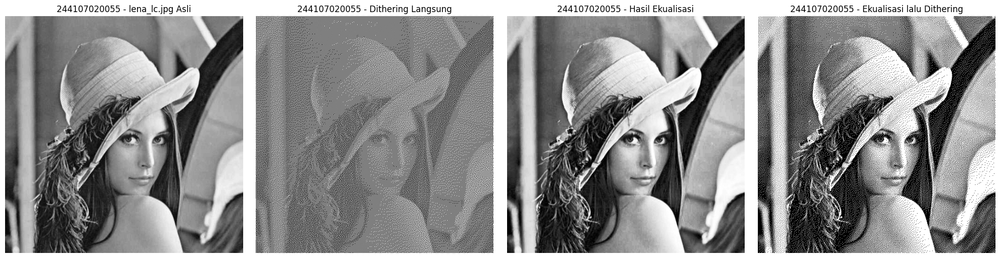

In [41]:
gray = cv.imread(CONTOH + '/lena_lc.jpg.jpeg', cv.IMREAD_GRAYSCALE)

hasil_langsung = floyd_steinberg(gray, L=2)

hasil_eq = cv.equalizeHist(gray)
hasil_eq_dither = floyd_steinberg(hasil_eq, L=2)

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - lena_lc.jpg Asli')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(hasil_langsung, cmap='gray')
plt.title(NIM + ' - Dithering Langsung')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(hasil_eq, cmap='gray')
plt.title(NIM + ' - Hasil Ekualisasi')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(hasil_eq_dither, cmap='gray')
plt.title(NIM + ' - Ekualisasi lalu Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

Tahap 2: KTM1a.jpeg

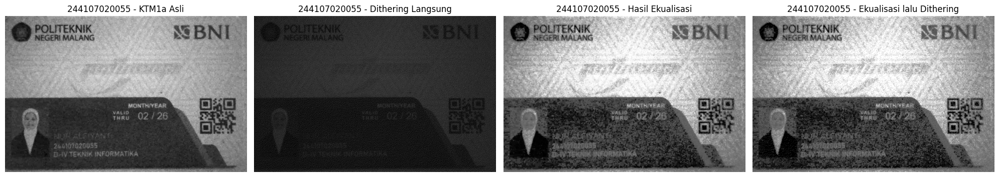

In [42]:
gray = cv.imread(BASE + '/' + 'KTM1a.jpeg', cv.IMREAD_GRAYSCALE)

hasil_langsung = floyd_steinberg(gray, L=2)

hasil_eq = cv.equalizeHist(gray)
hasil_eq_dither = floyd_steinberg(hasil_eq, L=2)

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - KTM1a Asli')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(hasil_langsung, cmap='gray')
plt.title(NIM + ' - Dithering Langsung')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(hasil_eq, cmap='gray')
plt.title(NIM + ' - Hasil Ekualisasi')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(hasil_eq_dither, cmap='gray')
plt.title(NIM + ' - Ekualisasi lalu Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

**Penjelasan:**

**Pada lena_lc.jpg**, dithering langsung menghasilkan citra yang sangat berisik dan detail wajah kurang jelas, karena citra sumber memiliki kontras rendah sehingga kuantisasi ke 2 level menghasilkan banyak noise dari difusi error. Setelah diekualisasi terlebih dahulu, hasil dithering menjadi jauh lebih tajam dan detail topi serta wajah lebih jelas terlihat, ini menjadi dasar verifikasi kode sebelum diuji pada KTM1a.

**Pada KTM1a**, perbedaannya bahkan lebih mencolok: dithering langsung menghasilkan citra yang sangat gelap dan nyaris tidak terbaca, karena foto aslinya diambil di ruangan gelap sehingga mayoritas piksel bernilai rendah. Dithering hanya mengkuantisasi nilai yang sudah ada tanpa menambah kontras, sehingga hasilnya tetap gelap. Sebaliknya, setelah diekualisasi terlebih dahulu, kontras citra diperbaiki secara signifikan sebelum dithering diterapkan, sehingga teks NIM, nama, dan tanggal pada kartu menjadi jauh lebih terbaca.